# Lab 7 — Image Segmentation and Feature Extraction

College: College of Computer Science and Information Technology  
Department: AI 
Course: ARTI407 – Image Processing  
Session Duration: 60 minutes  
Academic Year: 2025-2026

| Field | Value |
|---|---|
| Lab # | 7 |
| Student ID | 2230003194 |
| Student Name | Rawan alzaid |
| Class Name | ARTI407 – Image Processing |

Session Outcome #1:** Write a program which implements fundamental image processing algorithms.

Tools / Software:** Python 3, Anaconda, Jupyter / Spyder, OpenCV, NumPy, Pillow, scikit-image, Matplotlib.

This notebook contains four tasks:
1. Reference Task A — Canny edge detection.
2. Reference Task B — Harris corner detection.
3. Task 1 (graded) — Harris corner detection on a chessboard image.
4. Task 2 (graded) — Otsu's thresholding on a chosen image.


Setup  imports and sample images

We load three public-domain images shipped with scikit-image and persist them to `images/` so the rest of the notebook reads them from disk (matching the reference snippets that use `cv2.imread`).

In [1]:
# Imports shared by every task
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from skimage.filters import threshold_otsu

IMAGES_DIR = 'images'
OUTPUTS_DIR = 'outputs'
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# 1) Cameraman-style grayscale image for Canny edge detection
sample_gray = img_as_ubyte(data.camera())
cv2.imwrite(os.path.join(IMAGES_DIR, 'sample_gray.png'), sample_gray)

# 2) Chessboard / checkerboard pattern for Harris corner detection
checker = img_as_ubyte(data.checkerboard())
# Save as a 3-channel BGR image because Reference Task B uses cv2.imread (color)
checker_bgr = cv2.cvtColor(checker, cv2.COLOR_GRAY2BGR)
cv2.imwrite(os.path.join(IMAGES_DIR, 'chess.jpg'), checker_bgr)

# 3) Coins photo for Otsu thresholding (clear foreground / background)
coins = img_as_ubyte(data.coins())
cv2.imwrite(os.path.join(IMAGES_DIR, 'coins.png'), coins)

print('Saved sample images:')
for name in ('sample_gray.png', 'chess.jpg', 'coins.png'):
    p = os.path.join(IMAGES_DIR, name)
    print(f'  {p}  ({os.path.getsize(p)/1024:.1f} KB)')

print('OpenCV version:', cv2.__version__)

Saved sample images:
  images/sample_gray.png  (144.9 KB)
  images/chess.jpg  (8.7 KB)
  images/coins.png  (77.3 KB)
OpenCV version: 4.13.0


## Reference Task A — Canny Edge Detection

Apply OpenCV's Canny detector with thresholds (100, 200) on a grayscale image and display the original next to the edge image.

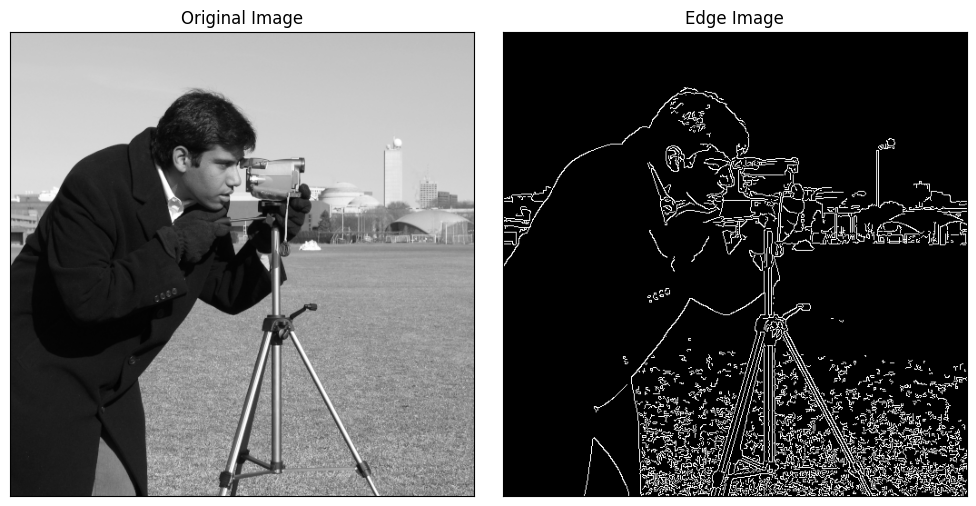

Saved -> outputs/refA_canny_figure.png


In [2]:
# --- Reference Task A: Canny Edge Detection ---
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load grayscale image (flag = 0)
img = cv2.imread('images/sample_gray.png', 0)

# Canny edge detection with low/high hysteresis thresholds
edges = cv2.Canny(img, 100, 200)

# Side-by-side display: original | edges
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.savefig('outputs/refA_canny_figure.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved -> outputs/refA_canny_figure.png')

## Reference Task B — Harris Corner Detection

Detect corners on a chessboard image using `cv2.cornerHarris` (`blockSize=2`, `ksize=3`, `k=0.04`), dilate the response, threshold at `0.01 * max`, and overlay big red dots.

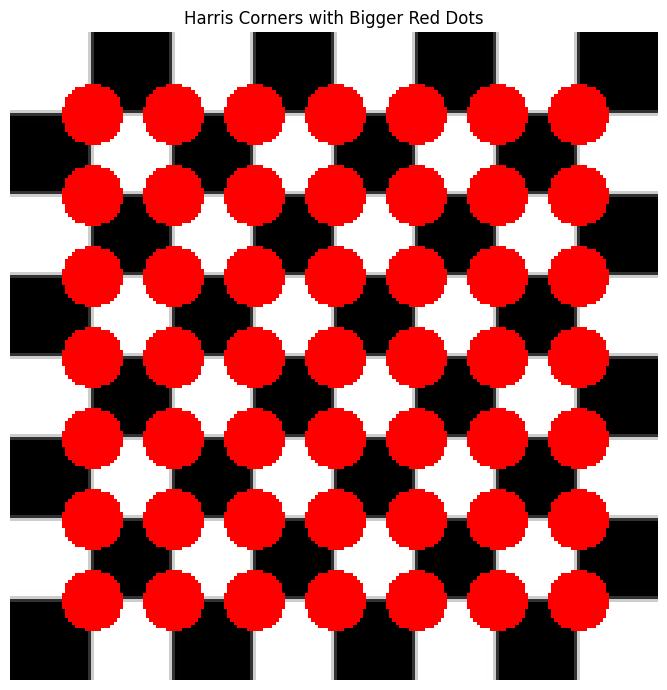

Saved -> outputs/refB_harris_figure.png


In [3]:
# --- Reference Task B: Harris Corner Detection ---
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load chessboard image (BGR by default)
image = cv2.imread('images/chess.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris response then dilate to thicken peaks
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)

# Pixels whose response exceeds the threshold are corners
threshold = 0.01 * harris.max()
corner_coords = np.argwhere(harris > threshold)

# Draw a filled red dot (BGR=(0,0,255)) of radius 7 at every corner pixel
for y, x in corner_coords:
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)

# Display: convert BGR -> RGB for matplotlib
plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners with Bigger Red Dots')
plt.axis('off')
plt.tight_layout()
plt.savefig('outputs/refB_harris_figure.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved -> outputs/refB_harris_figure.png')

 ## Task 1  Harris Corner Detection (graded)

Re-run the Harris pipeline on a fresh load of the chessboard image (so the previous cell's annotations don't carry over), report the number of detected corner pixels and the threshold value, and save the annotated output.

Harris max value : 90974056.000000
Threshold (1%)   : 909740.562500
Detected pixels  : 1225


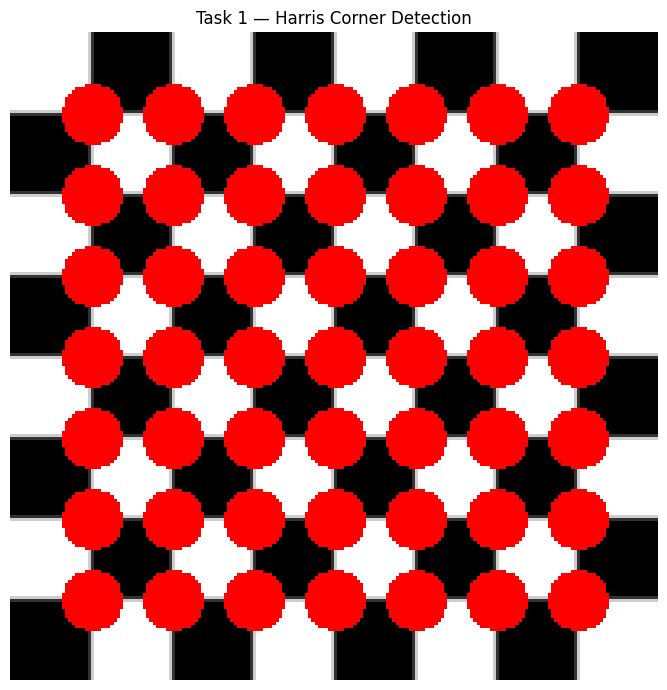

Saved -> outputs/task1_harris_figure.png, outputs/task1_harris_output.png


In [4]:
# --- Task 1: Harris Corner Detection output ---

# 1) Load the chessboard image (fresh copy)
image = cv2.imread('images/chess.jpg')
assert image is not None, 'chess.jpg not found in images/'

# 2) Convert to grayscale and to float32 (Harris requires float32 input)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_f32 = np.float32(gray)

# 3) Compute Harris response, then dilate so peaks are thicker
harris = cv2.cornerHarris(gray_f32, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)

# 4) Threshold and draw filled red circles (radius 7, BGR red)
threshold = 0.01 * harris.max()
corner_coords = np.argwhere(harris > threshold)
for y, x in corner_coords:
    cv2.circle(image, (int(x), int(y)), radius=7, color=(0, 0, 255), thickness=-1)

print(f'Harris max value : {harris.max():.6f}')
print(f'Threshold (1%)   : {threshold:.6f}')
print(f'Detected pixels  : {len(corner_coords)}')

# 5) Display (BGR -> RGB) and save figure + annotated image
plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Task 1 — Harris Corner Detection')
plt.axis('off')
plt.tight_layout()
plt.savefig('outputs/task1_harris_figure.png', dpi=150, bbox_inches='tight')
cv2.imwrite('outputs/task1_harris_output.png', image)
plt.show()

print('Saved -> outputs/task1_harris_figure.png, outputs/task1_harris_output.png')

## Task 2  Otsu's Thresholding (graded)

On a grayscale photo (the scikit-image *coins* sample), compute Otsu's threshold with both `cv2.threshold` (`THRESH_BINARY + THRESH_OTSU`) and `skimage.filters.threshold_otsu`, then show three subplots:
1. the original image,
2. its histogram with a red dashed vertical line at the Otsu threshold, and
3. the binarized image.

Print the computed threshold value.

Otsu threshold (OpenCV)      : 107.00
Otsu threshold (scikit-image): 107.00


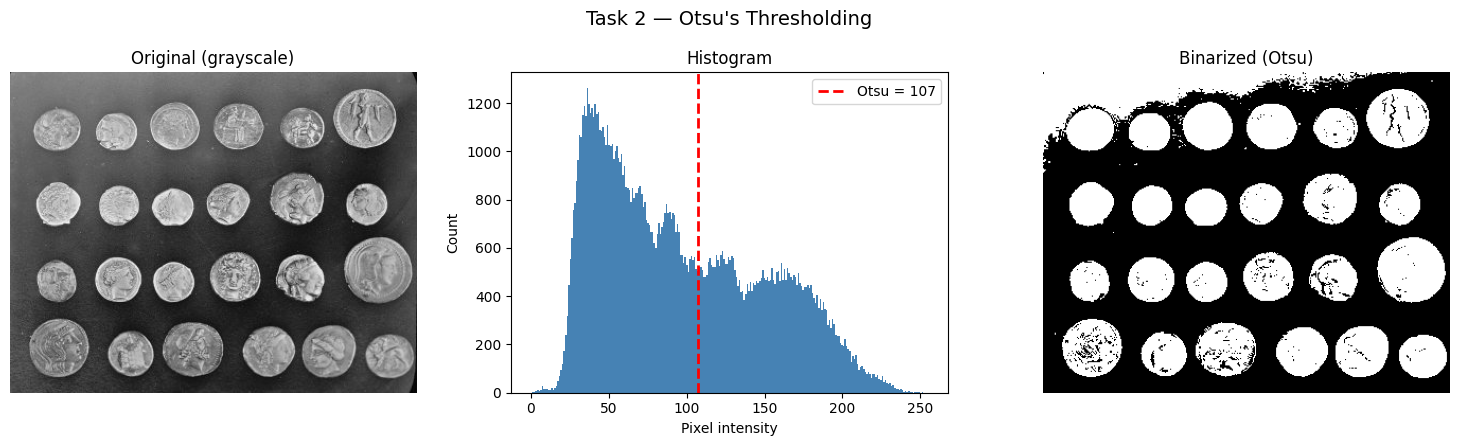

Saved -> outputs/task2_otsu_figure.png, outputs/task2_otsu_binary.png


In [5]:
# --- Task 2: Otsu's Thresholding ---

# 1) Load as grayscale
gray = cv2.imread('images/coins.png', cv2.IMREAD_GRAYSCALE)
assert gray is not None, 'coins.png not found in images/'

# 2) Otsu via OpenCV (threshold value is computed automatically; the supplied 0 is ignored)
otsu_cv, binary = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Cross-check with scikit-image
otsu_sk = threshold_otsu(gray)

print(f'Otsu threshold (OpenCV)      : {otsu_cv:.2f}')
print(f'Otsu threshold (scikit-image): {otsu_sk:.2f}')

# 3) Side-by-side: original | histogram + Otsu line | binarized
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (grayscale)')
axes[0].axis('off')

axes[1].hist(gray.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[1].axvline(otsu_cv, color='red', linestyle='--', linewidth=2,
                label=f'Otsu = {otsu_cv:.0f}')
axes[1].set_title('Histogram')
axes[1].set_xlabel('Pixel intensity')
axes[1].set_ylabel('Count')
axes[1].legend()

axes[2].imshow(binary, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Binarized (Otsu)')
axes[2].axis('off')

fig.suptitle("Task 2 — Otsu's Thresholding", fontsize=14)
plt.tight_layout()
plt.savefig('outputs/task2_otsu_figure.png', dpi=150, bbox_inches='tight')
cv2.imwrite('outputs/task2_otsu_binary.png', binary)
plt.show()

print('Saved -> outputs/task2_otsu_figure.png, outputs/task2_otsu_binary.png')

## References

1. OpenCV — Canny Edge Detection: <https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_canny/py_canny.html>
2. LearnOpenCV — Otsu Thresholding with OpenCV: <https://learnopencv.com/otsu-thresholding-with-opencv/>
3. scikit-image — Thresholding examples: <https://scikit-image.org/docs/0.25.x/auto_examples/segmentation/plot_thresholding.html>